In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
X = 8 * np.random.rand(200) - 4
y = (0.8 * X**2) + (0.7 * X) + 2 + np.random.randn(200)

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [4]:
X_train, X_test = pd.DataFrame(X_train), pd.DataFrame(X_test)

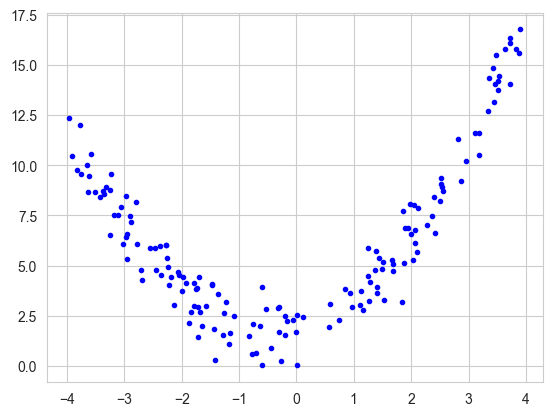

In [5]:
plt.plot(X_train, y_train,"b.")

# Using Polynomial Regression

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

In [10]:
class PolynomialRegression:
    def __init__(self):
        self.polynomial = None
        self.degree = None
        self.X_train = None
        self.X_test = None
        
    def fit(self, X_train, y_train, degree=2):
        self.degree = degree
        self.X_train = X_train
        self.y_train = y_train
        
        
        poly_trf = Pipeline([
            ("poly_trf",PolynomialFeatures(degree=degree,include_bias=True)),
            ("scaler",StandardScaler()),
            ("regression",LinearRegression())
        ])
        
        self.polynomial = poly_trf.fit(X_train, y_train)
        
    def predict(self, X_test):
        self.X_test = X_test
        return self.polynomial.predict(X_test)
    
    def generateRegressionLine(self):
        X_graph = np.linspace(self.X_train.min(), self.X_train.max(), 200).reshape(-1, 1)
        
        y_pred_graph = self.polynomial.predict(X_graph)
        
        plt.plot(self.X_train, self.y_train, "b.", label="Training Data")
        plt.plot(X_graph, y_pred_graph, "r-", label="Regression Line")
        plt.legend()
        plt.show()

In [15]:
polyReg = PolynomialRegression()

polyReg.fit(X_train, y_train, degree=7)

y_pred = polyReg.predict(X_test)
r2_score(y_test,y_pred)

0.9556234016049019

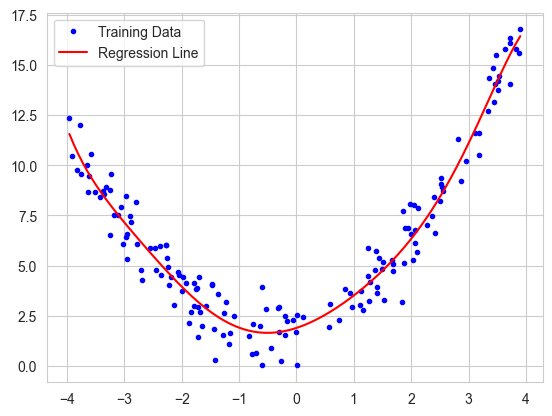

In [16]:
polyReg.generateRegressionLine()